# EDA — SmartCity 전력 회귀 모델 데이터 탐색 & 정제

**목적**: 5개 데이터소스 전체를 탐색하여 결측·이상값 기준을 도출하고,  
회귀 모델 투입용 정제 DataFrame을 확정한다.

| # | 데이터소스 | 로더 | 비고 |
|---|---|---|---|
| 1 | ASOS 기상 (서울 108) | `asos_daily.load_hourly` | 2006~2026 |
| 2 | KEPCO 전력소비량 | `kepco_merge.load_all` | 구별·용도별 |
| 3 | ONI (엘니뇨 지수) | `oni_loader.load_oni` | 1950~2026 |
| 4 | EPSIS 공급량·예비율 | `supply_loader.load_daily` | 2004~2026 |
| 5 | S-DoT 구별 기온 | `dong_offset.load_sdot_daily` | 2021~2025 |

**순서**  
0. 환경설정  
1. 소스별 로드 → 결측·이상값 탐색  
2. 정제 기준 적용 → 클린 DataFrame  
3. 상관관계 분석  
4. Feature Engineering  
5. 최종 Feature Matrix

---
## 0. 환경설정

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# 프로젝트 루트를 sys.path에 추가 (python/ 폴더 기준)
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# 한글 폰트
plt.rcParams['font.family'] = 'Noto Sans CJK KR'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('ROOT:', ROOT)
print('Python:', sys.version.split()[0])

ROOT: /Users/yejeonglee/Desktop/Unity/SmartCity
Python: 3.13.9


---
## 1. 데이터 로드 & 결측·이상값 탐색

각 소스를 Loader로 읽고, shape / 기간 / 결측률 / 기술통계를 확인한다.  
정제 기준은 섹션 2에서 결정한다.

### 1-1. ASOS 기상 (서울 108번 관측소)

In [2]:
from preprocess.asos_daily import load_hourly, to_daily, to_monthly

asos_h = load_hourly()
asos_d = to_daily(asos_h)
asos_m = to_monthly(asos_d)

print(f"시간별: {asos_h.shape}  |  기간: {asos_h['tm'].min().date()} ~ {asos_h['tm'].max().date()}")
print(f"일별:   {asos_d.shape}  |  월별: {asos_m.shape}")
print()

# ── 결측률 ──
print("=== 일별 결측률 ===")
print((asos_d.isnull().mean() * 100).round(2).to_string())
print()

# ── 기술통계 ──
print("=== 일별 기술통계 ===")
display(asos_d[['ta_mean','ta_max','ta_min','ws_mean','hm_mean']].describe().round(2))

시간별: (178943, 4)  |  기간: 2006-01-01 ~ 2026-05-31
일별:   (7456, 6)  |  월별: (245, 7)

=== 일별 결측률 ===
date       0.0
ta_mean    0.0
ta_max     0.0
ta_min     0.0
ws_mean    0.0
hm_mean    0.0

=== 일별 기술통계 ===


,ta_mean,ta_max,ta_min,ws_mean,hm_mean
count,7456.00,7456.00,7456.00,7456.00,7456.00
mean,13.15,17.55,9.36,2.40,61.26
std,10.60,10.74,10.74,0.80,14.84
min,-14.95,-11.20,-18.50,0.30,17.88
25%,4.14,8.20,0.40,1.84,50.25
50%,14.40,19.30,10.10,2.24,61.42
75%,22.63,26.90,18.90,2.80,71.92
max,33.74,39.40,30.40,7.40,99.58


findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Fo

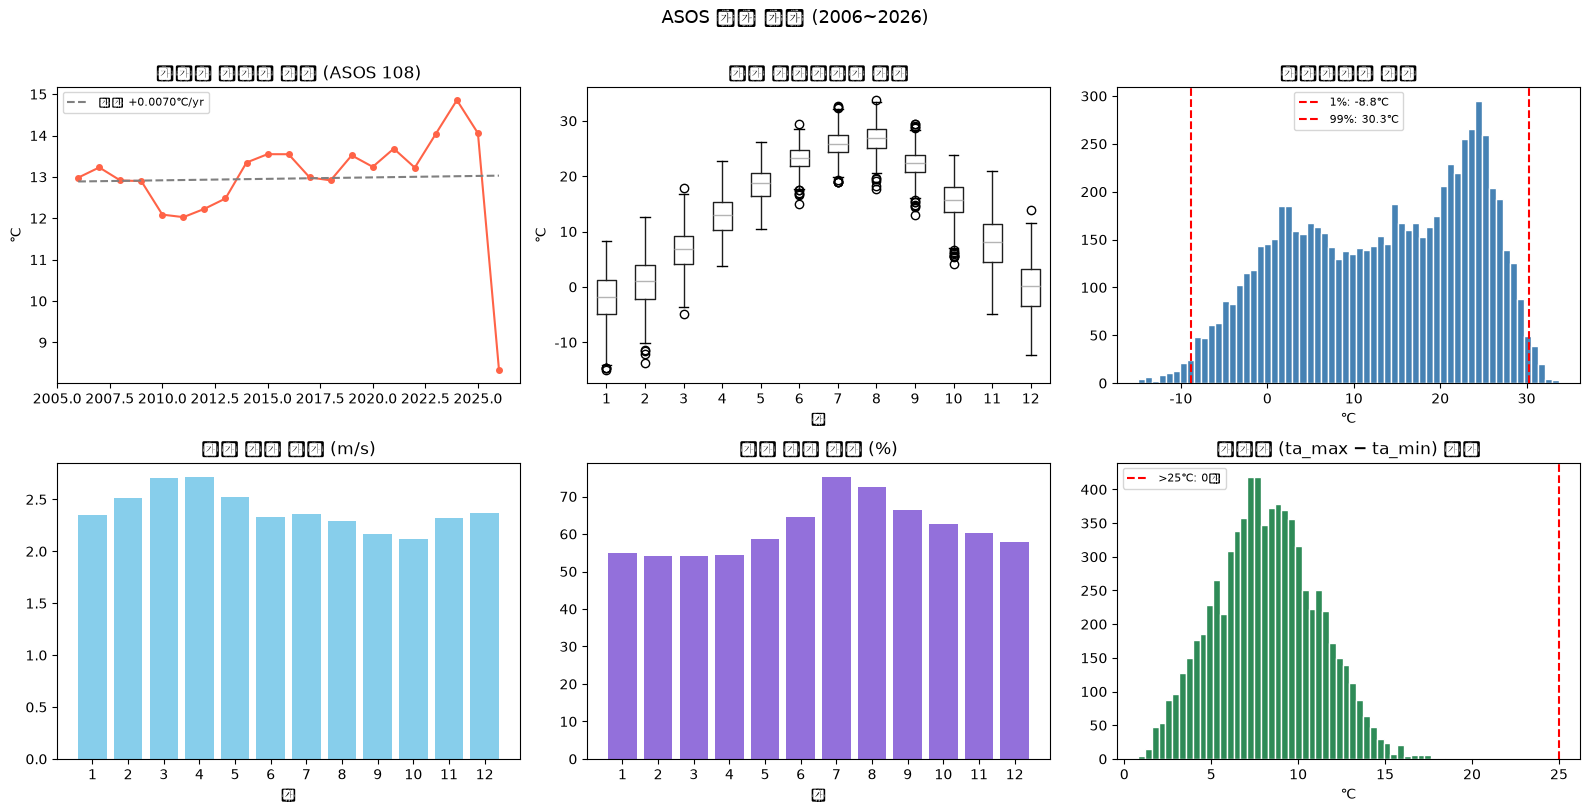


⚠️  일교차 > 25℃ 이상 행: 0건
   ta_mean 범위: -14.9 ~ 33.7℃  (물리적 범위 -25~40 확인)


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# 연도별 연평균 기온 추세
yearly_ta = asos_m.groupby('year')['ta_mean'].mean()
ax = axes[0, 0]
ax.plot(yearly_ta.index, yearly_ta.values, marker='o', color='tomato', ms=4)
z = np.polyfit(yearly_ta.index, yearly_ta.values, 1)
ax.plot(yearly_ta.index, np.polyval(z, yearly_ta.index), '--', color='gray',
        label=f'추세 {z[0]:+.4f}℃/yr')
ax.set_title('연도별 연평균 기온 (ASOS 108)')
ax.set_ylabel('℃'); ax.legend(fontsize=8)

# 월별 기온 box
asos_d['month'] = asos_d['date'].dt.month
asos_d.boxplot(column='ta_mean', by='month', ax=axes[0, 1], grid=False)
axes[0, 1].set_title('월별 일평균기온 분포')
axes[0, 1].set_xlabel('월'); axes[0, 1].set_ylabel('℃')
plt.sca(axes[0, 1]); plt.title('월별 일평균기온 분포')

# 이상값 확인: ta_mean 히스토그램
axes[0, 2].hist(asos_d['ta_mean'], bins=60, color='steelblue', edgecolor='white')
axes[0, 2].set_title('일평균기온 분포')
axes[0, 2].set_xlabel('℃')
q1, q3 = asos_d['ta_mean'].quantile([0.01, 0.99])
axes[0, 2].axvline(q1, color='red', ls='--', label=f'1%: {q1:.1f}℃')
axes[0, 2].axvline(q3, color='red', ls='--', label=f'99%: {q3:.1f}℃')
axes[0, 2].legend(fontsize=8)

# 월별 풍속
ws_m = asos_d.groupby('month')['ws_mean'].mean()
axes[1, 0].bar(ws_m.index, ws_m.values, color='skyblue')
axes[1, 0].set_title('월별 평균 풍속 (m/s)')
axes[1, 0].set_xlabel('월'); axes[1, 0].set_xticks(range(1, 13))

# 월별 습도
hm_m = asos_d.groupby('month')['hm_mean'].mean()
axes[1, 1].bar(hm_m.index, hm_m.values, color='mediumpurple')
axes[1, 1].set_title('월별 평균 습도 (%)')
axes[1, 1].set_xlabel('월'); axes[1, 1].set_xticks(range(1, 13))

# ta_max - ta_min 일교차
asos_d['dtr'] = asos_d['ta_max'] - asos_d['ta_min']
axes[1, 2].hist(asos_d['dtr'], bins=50, color='seagreen', edgecolor='white')
axes[1, 2].set_title('일교차 (ta_max − ta_min) 분포')
axes[1, 2].set_xlabel('℃')
# 이상값 탐지: 일교차 > 25℃는 센서 오류 의심
n_outlier = (asos_d['dtr'] > 25).sum()
axes[1, 2].axvline(25, color='red', ls='--', label=f'>25℃: {n_outlier}건')
axes[1, 2].legend(fontsize=8)

plt.suptitle('ASOS 기상 탐색 (2006~2026)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n⚠️  일교차 > 25℃ 이상 행: {n_outlier}건")
print(f"   ta_mean 범위: {asos_d['ta_mean'].min():.1f} ~ {asos_d['ta_mean'].max():.1f}℃  (물리적 범위 -25~40 확인)")

### 1-2. KEPCO 전력소비량

In [4]:
from preprocess.kepco_merge import load_all as kepco_load_all

kepco_raw = kepco_load_all()

print(f"shape: {kepco_raw.shape}")
print(f"연도: {kepco_raw['year'].min()} ~ {kepco_raw['year'].max()}")
print(f"구 수: {kepco_raw['district'].nunique()}  |  용도: {sorted(kepco_raw['usage_type'].unique())}")
print()
print("=== 결측률 ===")
print((kepco_raw.isnull().mean() * 100).round(2).to_string())
print()
print("=== 기술통계 (consumption_mwh) ===")
display(kepco_raw['consumption_mwh'].describe().round(1))

shape: (17620, 5)
연도: 2014 ~ 2026
구 수: 25  |  용도: ['가로등', '교육용', '농사용', '산업용', '심야', '일반용', '주택용']

=== 결측률 ===
year               0.0
month              0.0
district           0.0
usage_type         0.0
consumption_mwh    0.0

=== 기술통계 (consumption_mwh) ===


count     17620.0
mean      22877.0
std       38499.0
min           0.0
25%         753.3
50%        4154.5
75%       36120.2
max      358631.0
Name: consumption_mwh, dtype: float64

findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Font family 'Noto Sans CJK KR' not found.
findfont: Fo

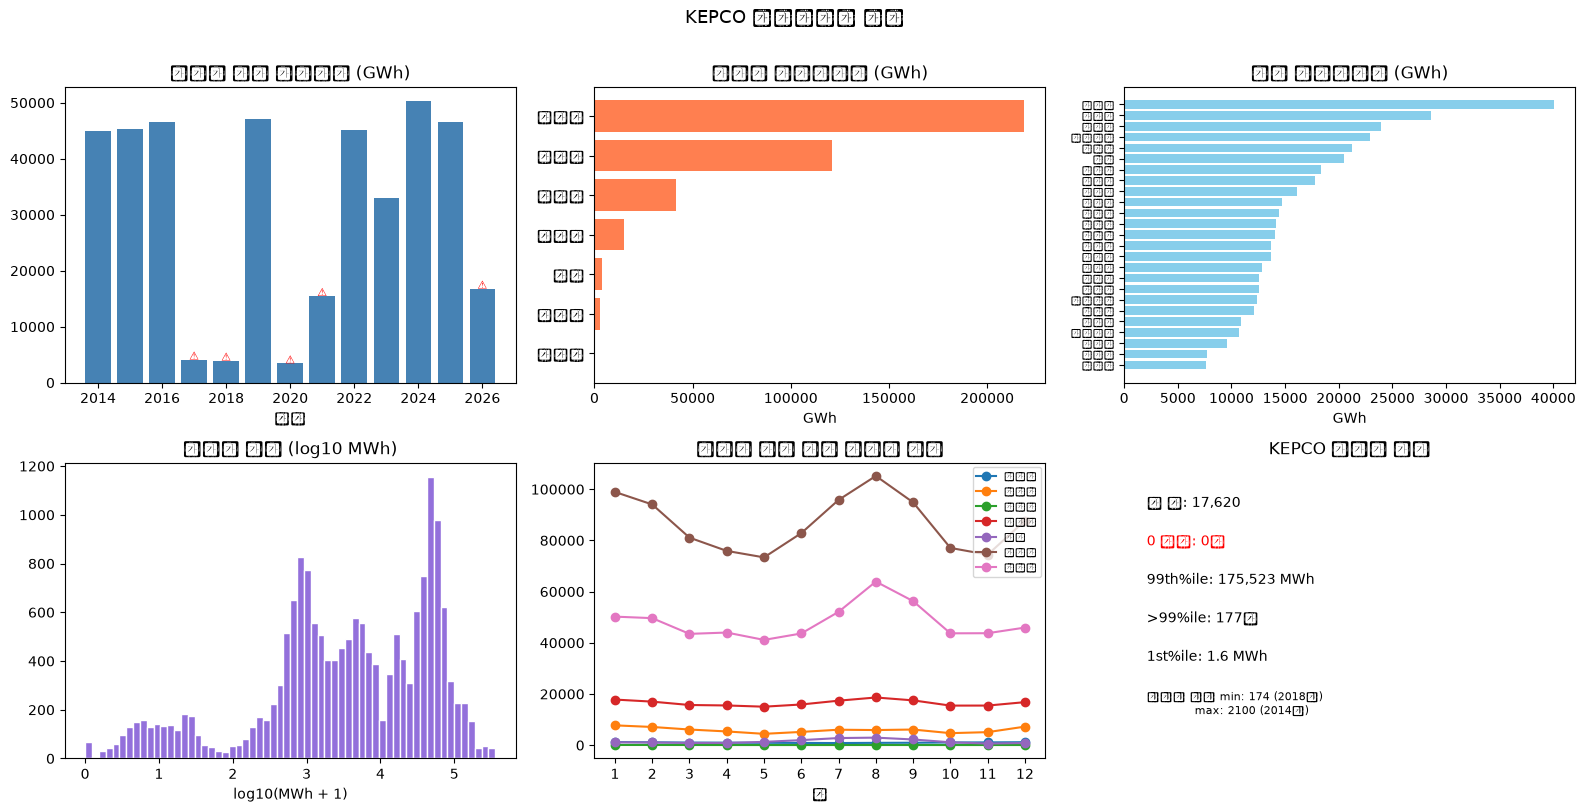


연도별 총소비량 (GWh):
year
2014    45019.0
2015    45382.0
2016    46493.0
2017     4136.0
2018     3949.0
2019    47167.0
2020     3451.0
2021    15486.0
2022    45180.0
2023    33061.0
2024    50352.0
2025    46617.0
2026    16799.0

누락 연도: []
⚠️  소비량이 중앙값 60% 미만인 연도 (데이터 불완전 의심): [2017, 2018, 2020, 2021, 2026]


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# 연도별 서울 총소비량
yearly_kwh = kepco_raw.groupby('year')['consumption_mwh'].sum() / 1e3  # GWh
ax = axes[0, 0]
ax.bar(yearly_kwh.index, yearly_kwh.values, color='steelblue')
ax.set_title('연도별 서울 총소비량 (GWh)')
ax.set_xlabel('연도')
# 연도별 값 차이가 크면 데이터 누락 의심 → 레이블 표시
for yr, val in yearly_kwh.items():
    if val < yearly_kwh.median() * 0.6:
        ax.text(yr, val + 1, '⚠️', ha='center', fontsize=8, color='red')

# 용도별 비중
usage_sum = kepco_raw.groupby('usage_type')['consumption_mwh'].sum().sort_values(ascending=True)
axes[0, 1].barh(usage_sum.index, usage_sum.values / 1e3, color='coral')
axes[0, 1].set_title('용도별 누적소비량 (GWh)')
axes[0, 1].set_xlabel('GWh')

# 구별 총소비량
dist_sum = kepco_raw.groupby('district')['consumption_mwh'].sum().sort_values(ascending=True)
axes[0, 2].barh(dist_sum.index, dist_sum.values / 1e3, color='skyblue')
axes[0, 2].set_title('구별 누적소비량 (GWh)')
axes[0, 2].set_xlabel('GWh')
axes[0, 2].tick_params(axis='y', labelsize=7)

# 소비량 분포 (로그)
axes[1, 0].hist(np.log10(kepco_raw['consumption_mwh'] + 1), bins=60,
                color='mediumpurple', edgecolor='white')
axes[1, 0].set_title('소비량 분포 (log10 MWh)')
axes[1, 0].set_xlabel('log10(MWh + 1)')

# 용도×월별 평균 패턴
usage_month = kepco_raw.groupby(['month', 'usage_type'])['consumption_mwh'].mean().unstack()
usage_month.plot(ax=axes[1, 1], marker='o', legend=True)
axes[1, 1].set_title('용도별 월별 평균 소비량 패턴')
axes[1, 1].set_xlabel('월'); axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].legend(fontsize=7)

# 이상값: 0 또는 음수, 극단값 확인
p99 = kepco_raw['consumption_mwh'].quantile(0.99)
p01 = kepco_raw['consumption_mwh'].quantile(0.01)
n_zero = (kepco_raw['consumption_mwh'] <= 0).sum()
n_high = (kepco_raw['consumption_mwh'] > p99).sum()
axes[1, 2].text(0.05, 0.85, f"총 행: {len(kepco_raw):,}", transform=axes[1, 2].transAxes)
axes[1, 2].text(0.05, 0.72, f"0 이하: {n_zero}건", transform=axes[1, 2].transAxes, color='red')
axes[1, 2].text(0.05, 0.59, f"99th%ile: {p99:,.0f} MWh", transform=axes[1, 2].transAxes)
axes[1, 2].text(0.05, 0.46, f">99%ile: {n_high}건", transform=axes[1, 2].transAxes)
axes[1, 2].text(0.05, 0.33, f"1st%ile: {p01:,.1f} MWh", transform=axes[1, 2].transAxes)

# 연도별 행 수 (커버리지 확인)
yr_cnt = kepco_raw.groupby('year').size()
axes[1, 2].text(0.05, 0.15,
    f"연도별 행수 min: {yr_cnt.min()} ({yr_cnt.idxmin()}년)\n"
    f"            max: {yr_cnt.max()} ({yr_cnt.idxmax()}년)",
    transform=axes[1, 2].transAxes, fontsize=8)
axes[1, 2].set_title('KEPCO 이상값 요약')
axes[1, 2].axis('off')

plt.suptitle('KEPCO 전력소비량 탐색', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print("\n연도별 총소비량 (GWh):")
print(yearly_kwh.round(0).to_string())
print()
# 누락 연도 탐지
all_years = set(range(kepco_raw['year'].min(), kepco_raw['year'].max() + 1))
present = set(kepco_raw['year'].unique())
missing_years = sorted(all_years - present)
low_coverage = yearly_kwh[yearly_kwh < yearly_kwh.median() * 0.6].index.tolist()
print(f"누락 연도: {missing_years}")
print(f"⚠️  소비량이 중앙값 60% 미만인 연도 (데이터 불완전 의심): {low_coverage}")

### 1-3. ONI (엘니뇨-남방진동 지수)

In [6]:
from python.preprocess.oni_loader import load_oni

oni_raw = load_oni()

print(f"shape: {oni_raw.shape}  |  기간: {oni_raw['year'].min()} ~ {oni_raw['year'].max()}")
print()
print("=== 결측률 ===")
print((oni_raw.isnull().mean() * 100).round(2).to_string())
print()
print("=== 기술통계 ===")
display(oni_raw['oni'].describe().round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 시계열 (2006~)
oni_plot = oni_raw[oni_raw['year'] >= 2006].copy()
dates = pd.to_datetime(oni_plot[['year', 'month']].assign(day=1))
axes[0].fill_between(dates, oni_plot['oni'], 0,
    where=oni_plot['oni'] > 0.5, color='tomato', alpha=0.7, label='El Niño (>0.5)')
axes[0].fill_between(dates, oni_plot['oni'], 0,
    where=oni_plot['oni'] < -0.5, color='steelblue', alpha=0.7, label='La Niña (<-0.5)')
axes[0].plot(dates, oni_plot['oni'], color='gray', lw=0.8)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('ONI 시계열 (2006~)')
axes[0].legend(fontsize=8)

# 분포
axes[1].hist(oni_raw['oni'], bins=35, color='goldenrod', edgecolor='white')
axes[1].axvline(0.5,  color='tomato',    ls='--', label='El Niño 기준 (+0.5)')
axes[1].axvline(-0.5, color='steelblue', ls='--', label='La Niña 기준 (-0.5)')
axes[1].set_title('ONI 분포 (전체 기간)')
axes[1].set_xlabel('ONI')
axes[1].legend(fontsize=8)

# 월별 ONI 평균 (계절성 확인)
oni_month = oni_raw.groupby('month')['oni'].mean()
axes[2].bar(oni_month.index, oni_month.values,
            color=['tomato' if v > 0 else 'steelblue' for v in oni_month.values])
axes[2].axhline(0, color='k', lw=0.5)
axes[2].set_title('월별 평균 ONI')
axes[2].set_xlabel('월'); axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

print(f"\nEl Niño 월 (>0.5):   {(oni_raw['oni'] > 0.5).sum()}개월")
print(f"La Niña 월 (<-0.5):  {(oni_raw['oni'] < -0.5).sum()}개월")
print(f"중립 (-0.5~0.5):     {((oni_raw['oni'] >= -0.5) & (oni_raw['oni'] <= 0.5)).sum()}개월")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/yejeonglee/Desktop/Unity/SmartCity/data/file/oni.csv'

### 1-4. EPSIS 전력공급량·예비율

일별: (8014, 12)  |  기간: 2004-06-28 ~ 2026-06-20
월별: (265, 6)

=== 결측률 (핵심 컬럼) ===
supply_mw       0.0
peak_mw         0.0
reserve_mw      0.0
reserve_rate    0.0

=== 기술통계 ===


,supply_mw,peak_mw,reserve_mw,reserve_rate
count,8014.0,8014.0,8014.0,8014.0
mean,79303.7,63599.8,15703.7,25.4
std,13800.7,11523.3,6922.2,12.0
min,49988.0,28783.0,2791.0,3.8
25%,67534.0,55063.0,10571.0,17.1
50%,80042.0,63879.5,14552.5,23.0
75%,90156.8,71257.8,19651.0,31.8
max,111539.0,97115.0,44040.0,95.7


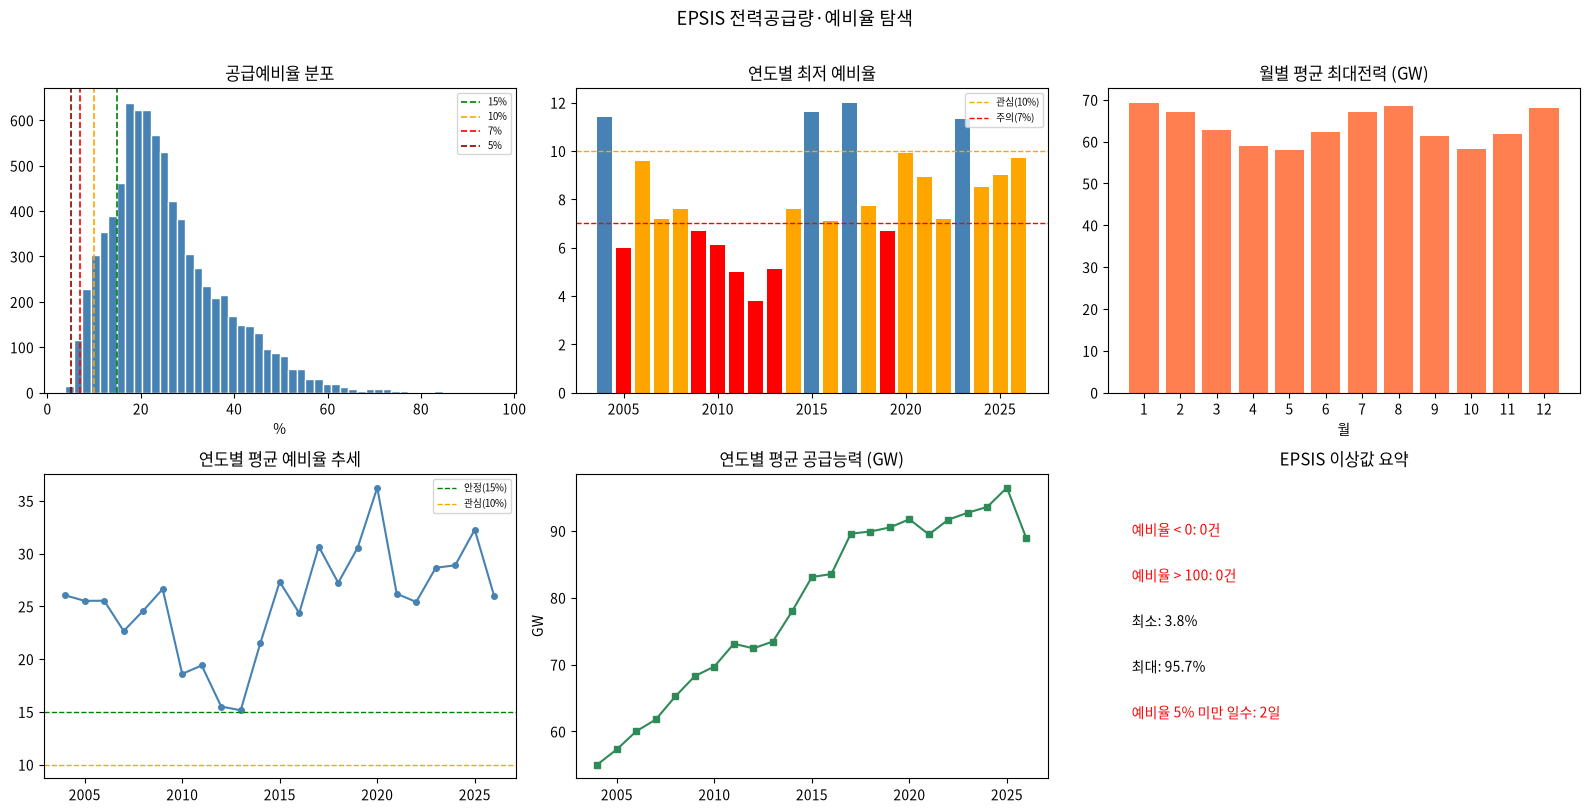

In [ ]:
from python.preprocess.supply_loader import load_daily as supply_load_daily, load_monthly as supply_load_monthly

supply_d = supply_load_daily()
supply_m = supply_load_monthly()

print(f"일별: {supply_d.shape}  |  기간: {supply_d['date'].min().date()} ~ {supply_d['date'].max().date()}")
print(f"월별: {supply_m.shape}")
print()
print("=== 결측률 (핵심 컬럼) ===")
key_cols = ['supply_mw', 'peak_mw', 'reserve_mw', 'reserve_rate']
print((supply_d[key_cols].isnull().mean() * 100).round(2).to_string())
print()
print("=== 기술통계 ===")
display(supply_d[key_cols].describe().round(1))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# 예비율 분포
axes[0, 0].hist(supply_d['reserve_rate'].dropna(), bins=50, color='steelblue', edgecolor='white')
for lv, c in [(15, 'green'), (10, 'orange'), (7, 'red'), (5, 'darkred')]:
    axes[0, 0].axvline(lv, color=c, ls='--', lw=1.2, label=f'{lv}%')
axes[0, 0].set_title('공급예비율 분포')
axes[0, 0].set_xlabel('%'); axes[0, 0].legend(fontsize=7)

# 연도별 최저 예비율
min_rate = supply_d.groupby('year')['reserve_rate'].min()
bar_colors = ['red' if v < 7 else 'orange' if v < 10 else 'steelblue' for v in min_rate.values]
axes[0, 1].bar(min_rate.index, min_rate.values, color=bar_colors)
axes[0, 1].axhline(10, color='orange', ls='--', lw=1, label='관심(10%)')
axes[0, 1].axhline(7,  color='red',    ls='--', lw=1, label='주의(7%)')
axes[0, 1].set_title('연도별 최저 예비율')
axes[0, 1].legend(fontsize=7)

# 월별 평균 최대전력
peak_month = supply_d.groupby(supply_d['date'].dt.month)['peak_mw'].mean()
axes[0, 2].bar(peak_month.index, peak_month.values / 1000, color='coral')
axes[0, 2].set_title('월별 평균 최대전력 (GW)')
axes[0, 2].set_xlabel('월'); axes[0, 2].set_xticks(range(1, 13))

# 예비율 시계열 (연도별 추세)
supply_yr = supply_d.groupby('year')['reserve_rate'].mean()
axes[1, 0].plot(supply_yr.index, supply_yr.values, marker='o', color='steelblue', ms=4)
axes[1, 0].axhline(15, color='green', ls='--', lw=1, label='안정(15%)')
axes[1, 0].axhline(10, color='orange', ls='--', lw=1, label='관심(10%)')
axes[1, 0].set_title('연도별 평균 예비율 추세')
axes[1, 0].legend(fontsize=7)

# 공급능력 추세
supply_yr_mw = supply_d.groupby('year')['supply_mw'].mean()
axes[1, 1].plot(supply_yr_mw.index, supply_yr_mw.values / 1000, marker='s', color='seagreen', ms=4)
axes[1, 1].set_title('연도별 평균 공급능력 (GW)')
axes[1, 1].set_ylabel('GW')

# 이상값: reserve_rate < 0 또는 > 100
n_neg  = (supply_d['reserve_rate'] < 0).sum()
n_over = (supply_d['reserve_rate'] > 100).sum()
axes[1, 2].text(0.05, 0.8, f"예비율 < 0: {n_neg}건", transform=axes[1, 2].transAxes, color='red')
axes[1, 2].text(0.05, 0.65, f"예비율 > 100: {n_over}건", transform=axes[1, 2].transAxes, color='red')
axes[1, 2].text(0.05, 0.50, f"최소: {supply_d['reserve_rate'].min():.1f}%", transform=axes[1, 2].transAxes)
axes[1, 2].text(0.05, 0.35, f"최대: {supply_d['reserve_rate'].max():.1f}%", transform=axes[1, 2].transAxes)
axes[1, 2].text(0.05, 0.20, f"예비율 5% 미만 일수: {(supply_d['reserve_rate'] < 5).sum()}일",
    transform=axes[1, 2].transAxes, color='red')
axes[1, 2].set_title('EPSIS 이상값 요약')
axes[1, 2].axis('off')

plt.suptitle('EPSIS 전력공급량·예비율 탐색', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 1-5. S-DoT 구별 기온 (서울 도시데이터 센서)

In [ ]:
from python.preprocess.dong_offset import load_sdot_daily

sdot_raw = load_sdot_daily()

print(f"shape: {sdot_raw.shape}")
print(f"기간: {sdot_raw['date'].min().date()} ~ {sdot_raw['date'].max().date()}")
print(f"구 수: {sdot_raw['gu'].nunique()}")
print()
print("=== 결측률 ===")
print((sdot_raw.isnull().mean() * 100).round(2).to_string())
print()
print("=== 기술통계 ===")
display(sdot_raw[['ta_min', 'ta_max', 'ta_mean', 'ws_mean']].describe().round(2))

shape: (24573, 6)
기간: 2021-11-09 ~ 2025-12-07
구 수: 25

=== 결측률 ===
gu          0.0
date        0.0
ta_min      0.0
ta_max      0.0
ta_mean     0.0
ws_mean    43.3

=== 기술통계 ===


,ta_min,ta_max,ta_mean,ws_mean
count,24573.00,24573.00,24573.00,13933.00
mean,-9.98,23.71,14.47,0.64
std,24.32,11.32,10.14,0.56
min,-40.00,-5.20,-17.26,0.00
25%,-40.00,13.90,5.55,0.32
50%,-2.80,25.50,16.01,0.52
75%,11.20,32.60,22.87,0.81
max,29.70,80.00,34.37,11.15


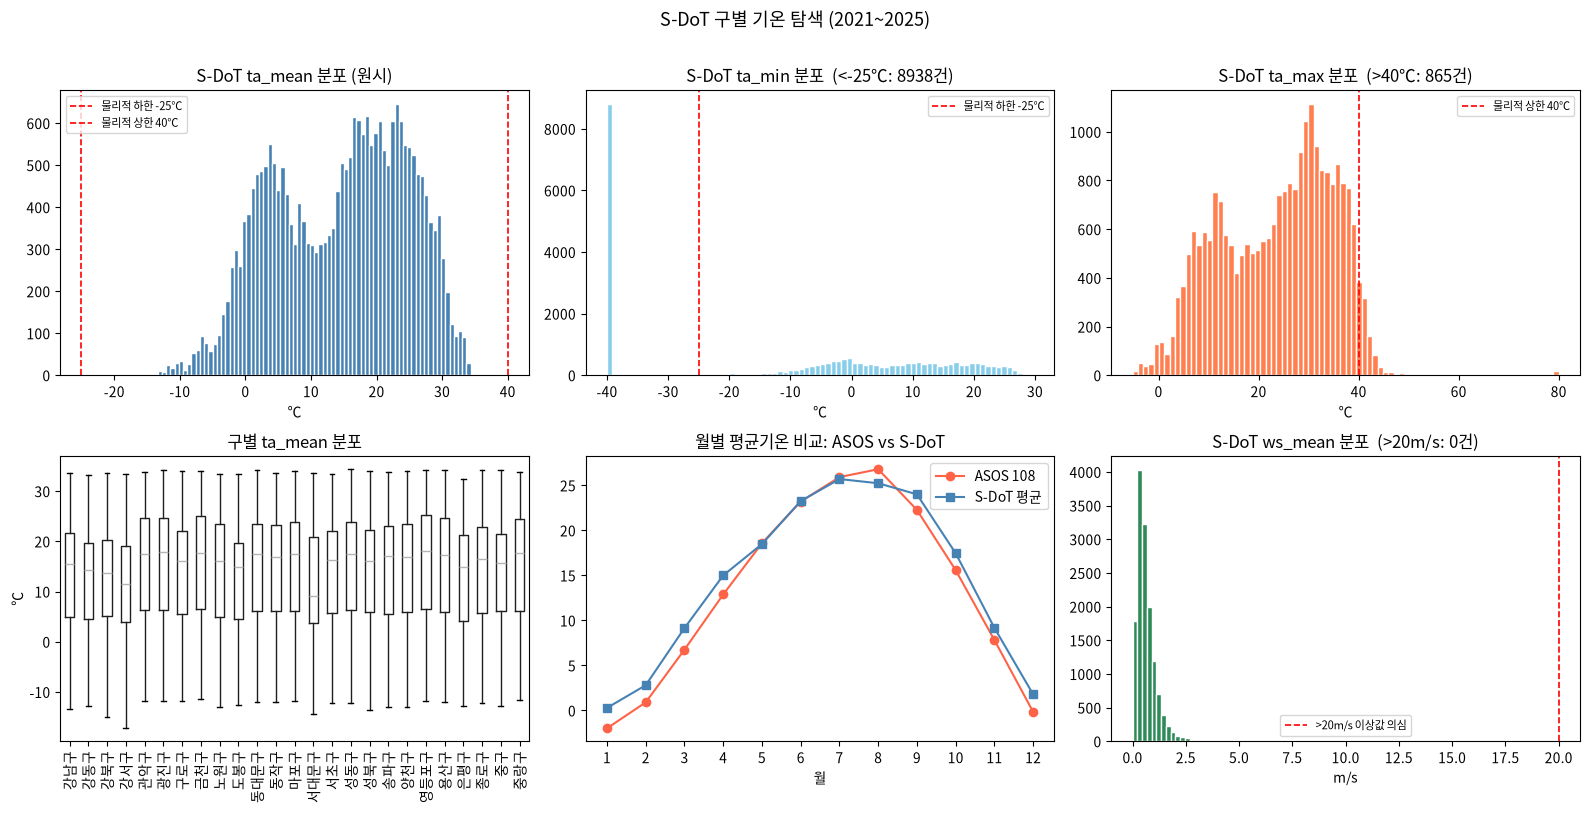


S-DoT 이상값 요약:
  ta_mean < -25℃:  0건
  ta_mean > 40℃:   0건
  ta_min  < -25℃:  8938건
  ta_max  > 40℃:   865건
  ws_mean > 20m/s: 0건
  ws_mean 결측:    10640건 (43.3%)


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# ta_mean 분포 전체
axes[0, 0].hist(sdot_raw['ta_mean'], bins=80, color='steelblue', edgecolor='white')
axes[0, 0].axvline(-25, color='red', ls='--', lw=1.2, label='물리적 하한 -25℃')
axes[0, 0].axvline(40,  color='red', ls='--', lw=1.2, label='물리적 상한 40℃')
axes[0, 0].set_title('S-DoT ta_mean 분포 (원시)')
axes[0, 0].set_xlabel('℃'); axes[0, 0].legend(fontsize=8)

# ta_min 분포 (이상값 확인: -40℃ 등)
axes[0, 1].hist(sdot_raw['ta_min'], bins=80, color='skyblue', edgecolor='white')
axes[0, 1].axvline(-25, color='red', ls='--', lw=1.2, label='물리적 하한 -25℃')
n_below = (sdot_raw['ta_min'] < -25).sum()
axes[0, 1].set_title(f'S-DoT ta_min 분포  (<-25℃: {n_below}건)')
axes[0, 1].set_xlabel('℃'); axes[0, 1].legend(fontsize=8)

# ta_max 분포
axes[0, 2].hist(sdot_raw['ta_max'], bins=80, color='coral', edgecolor='white')
axes[0, 2].axvline(40, color='red', ls='--', lw=1.2, label='물리적 상한 40℃')
n_above = (sdot_raw['ta_max'] > 40).sum()
axes[0, 2].set_title(f'S-DoT ta_max 분포  (>40℃: {n_above}건)')
axes[0, 2].set_xlabel('℃'); axes[0, 2].legend(fontsize=8)

# 구별 ta_mean 박스 (이상값 패턴 확인)
sdot_raw.boxplot(column='ta_mean', by='gu', ax=axes[1, 0], grid=False, rot=90)
axes[1, 0].set_title('구별 ta_mean 분포')
axes[1, 0].set_xlabel(''); axes[1, 0].set_ylabel('℃')
plt.sca(axes[1, 0]); plt.title('구별 ta_mean 분포')

# ASOS vs S-DoT 월별 비교
sdot_raw['month'] = sdot_raw['date'].dt.month
sdot_mon = sdot_raw.groupby('month')['ta_mean'].mean()
asos_mon = asos_d.groupby('month')['ta_mean'].mean()
axes[1, 1].plot(asos_mon.index, asos_mon.values, marker='o', color='tomato', label='ASOS 108')
axes[1, 1].plot(sdot_mon.index, sdot_mon.values, marker='s', color='steelblue', label='S-DoT 평균')
axes[1, 1].set_title('월별 평균기온 비교: ASOS vs S-DoT')
axes[1, 1].set_xlabel('월'); axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].legend()

# ws_mean 분포 (결측 외 값 확인)
ws_valid = sdot_raw['ws_mean'].dropna()
axes[1, 2].hist(ws_valid, bins=50, color='seagreen', edgecolor='white')
axes[1, 2].axvline(20, color='red', ls='--', lw=1.2, label=f'>20m/s 이상값 의심')
n_ws_high = (ws_valid > 20).sum()
axes[1, 2].set_title(f'S-DoT ws_mean 분포  (>20m/s: {n_ws_high}건)')
axes[1, 2].set_xlabel('m/s'); axes[1, 2].legend(fontsize=8)

plt.suptitle('S-DoT 구별 기온 탐색 (2021~2025)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# 이상값 범위별 건수 요약
print("\nS-DoT 이상값 요약:")
print(f"  ta_mean < -25℃:  {(sdot_raw['ta_mean'] < -25).sum()}건")
print(f"  ta_mean > 40℃:   {(sdot_raw['ta_mean'] > 40).sum()}건")
print(f"  ta_min  < -25℃:  {(sdot_raw['ta_min']  < -25).sum()}건")
print(f"  ta_max  > 40℃:   {(sdot_raw['ta_max']  > 40).sum()}건")
print(f"  ws_mean > 20m/s: {(sdot_raw['ws_mean'] > 20).sum()}건")
print(f"  ws_mean 결측:    {sdot_raw['ws_mean'].isna().sum()}건 ({sdot_raw['ws_mean'].isna().mean()*100:.1f}%)")

---
## 2. 데이터 정제 기준 적용

섹션 1에서 확인한 이상값 기준을 적용하여 클린 DataFrame을 생성한다.

| 소스 | 정제 기준 |
|---|---|
| ASOS | 결측 없음 — 그대로 사용 |
| KEPCO | 총소비량이 중앙값 60% 미만인 연도 제외 (불완전 파일) |
| ONI | 이미 Loader에서 [-2.5, 2.5] 범위 필터 적용 — 그대로 사용 |
| EPSIS | 예비율 < 0 또는 > 100% 제거 |
| S-DoT | ta_mean [-25, 40] / ta_min [-25, 35] / ta_max [-10, 45] 범위 밖 → NaN 처리 후 구별 재집계 |

In [ ]:
# ── 2-1. ASOS: 그대로 사용 ────────────────────────────────────────────────
asos_clean_d = asos_d.copy()
asos_clean_m = asos_m.copy()
print(f"ASOS 일별 클린: {asos_clean_d.shape}")

# ── 2-2. KEPCO: 불완전 연도 제거 ─────────────────────────────────────────
yearly_total = kepco_raw.groupby('year')['consumption_mwh'].sum()
median_total = yearly_total.median()
valid_years  = yearly_total[yearly_total >= median_total * 0.6].index
kepco_clean  = kepco_raw[kepco_raw['year'].isin(valid_years)].copy()

removed_years = sorted(set(kepco_raw['year'].unique()) - set(valid_years))
print(f"\nKEPCO 제거 연도: {removed_years}")
print(f"KEPCO 클린: {kepco_raw.shape} → {kepco_clean.shape}")

# ── 2-3. ONI: 그대로 사용 ─────────────────────────────────────────────────
oni_clean = oni_raw.copy()
print(f"\nONI 클린: {oni_clean.shape}")

# ── 2-4. EPSIS: 예비율 범위 필터 ─────────────────────────────────────────
supply_clean_d = supply_d[
    (supply_d['reserve_rate'] >= 0) &
    (supply_d['reserve_rate'] <= 100)
].copy()
supply_clean_m = supply_clean_d.groupby(['year', 'month']).agg(
    supply_mw_mean=('supply_mw', 'mean'),
    peak_mw_max=('peak_mw', 'max'),
    reserve_rate_mean=('reserve_rate', 'mean'),
    reserve_rate_min=('reserve_rate', 'min'),
).reset_index()
print(f"\nEPSIS 일별 클린: {supply_d.shape} → {supply_clean_d.shape}")

# ── 2-5. S-DoT: 물리적 범위 필터 후 구별 재집계 ──────────────────────────
TA_MEAN_MIN, TA_MEAN_MAX = -25.0, 40.0
TA_MIN_MIN,  TA_MIN_MAX  = -25.0, 35.0
TA_MAX_MIN,  TA_MAX_MAX  =  -10.0, 45.0
WS_MAX = 20.0

sdot_c = sdot_raw.copy()
for col, lo, hi in [
    ('ta_mean', TA_MEAN_MIN, TA_MEAN_MAX),
    ('ta_min',  TA_MIN_MIN,  TA_MIN_MAX),
    ('ta_max',  TA_MAX_MIN,  TA_MAX_MAX),
]:
    mask = (sdot_c[col] < lo) | (sdot_c[col] > hi)
    sdot_c.loc[mask, col] = np.nan

sdot_c.loc[sdot_c['ws_mean'] > WS_MAX, 'ws_mean'] = np.nan

# ta_mean이 NaN인 행 제거 후 구별 재집계
sdot_c = sdot_c.dropna(subset=['ta_mean'])
sdot_clean = sdot_c.groupby(['gu', 'date'], as_index=False).agg(
    ta_min=('ta_min', 'min'),
    ta_max=('ta_max', 'max'),
    ta_mean=('ta_mean', 'mean'),
    ws_mean=('ws_mean', 'mean'),
)
print(f"\nS-DoT 클린: {sdot_raw.shape} → {sdot_clean.shape}")
print(f"  ta_mean NaN 제거 후 구 수: {sdot_clean['gu'].nunique()}")
print(f"  ws_mean 결측: {sdot_clean['ws_mean'].isna().mean()*100:.1f}%")

ASOS 일별 클린: (7456, 8)

KEPCO 제거 연도: [np.int64(2017), np.int64(2018), np.int64(2020), np.int64(2021), np.int64(2026)]
KEPCO 클린: (17620, 5) → (15701, 5)

ONI 클린: (913, 3)

EPSIS 일별 클린: (8014, 12) → (8014, 12)

S-DoT 클린: (24573, 7) → (24573, 6)
  ta_mean NaN 제거 후 구 수: 25
  ws_mean 결측: 43.3%


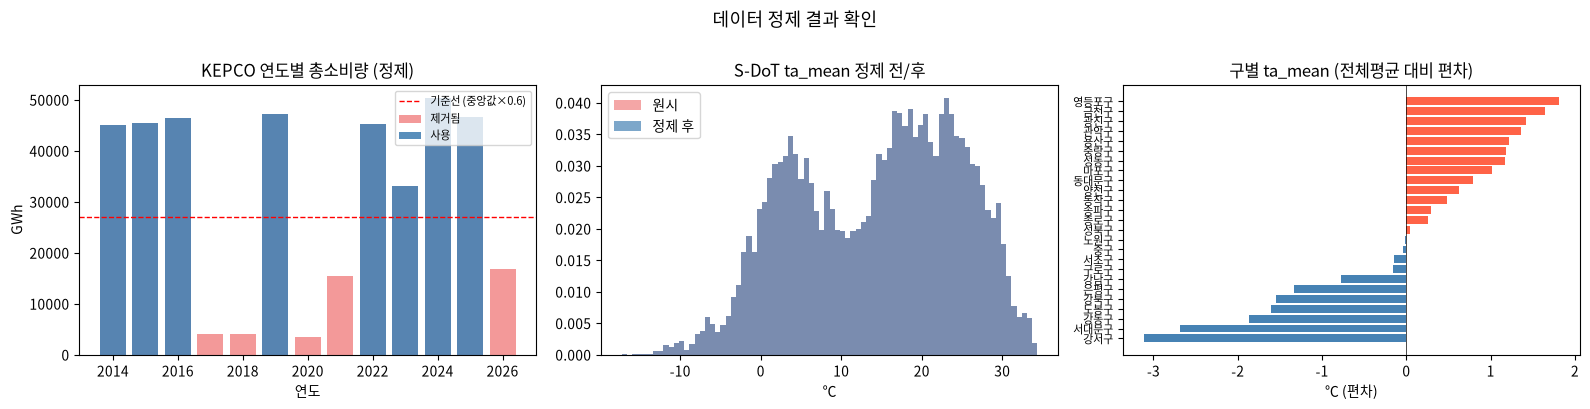


=== 클린 DataFrame 요약 ===
asos_clean_d : (7456, 8)  (2006-01-01 ~ 2026-05-31)
kepco_clean  : (15701, 5)  (연도: 2014~2025)
oni_clean    : (913, 3)
supply_clean_d: (8014, 12)
sdot_clean   : (24573, 7)  (2021-11-09 ~ 2025-12-07)


In [ ]:
# 정제 전/후 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# KEPCO: 연도별 총소비량 정제 전/후
ax = axes[0]
ax.bar(yearly_total.index, yearly_total.values / 1e3, color='lightcoral', label='제거됨', alpha=0.8)
ax.bar(yearly_total[valid_years].index, yearly_total[valid_years].values / 1e3,
       color='steelblue', label='사용', alpha=0.9)
ax.axhline(median_total * 0.6 / 1e3, color='red', ls='--', lw=1, label='기준선 (중앙값×0.6)')
ax.set_title('KEPCO 연도별 총소비량 (정제)')
ax.set_xlabel('연도'); ax.set_ylabel('GWh'); ax.legend(fontsize=8)

# S-DoT: ta_mean 정제 전/후
axes[1].hist(sdot_raw['ta_mean'], bins=80, color='lightcoral', alpha=0.7, label='원시', density=True)
axes[1].hist(sdot_clean['ta_mean'], bins=80, color='steelblue', alpha=0.7, label='정제 후', density=True)
axes[1].set_title('S-DoT ta_mean 정제 전/후')
axes[1].set_xlabel('℃'); axes[1].legend()

# S-DoT: 구별 정제 후 ta_mean 박스
sdot_clean['month'] = sdot_clean['date'].dt.month
sdot_gu_mon = sdot_clean.groupby('gu')['ta_mean'].mean().sort_values()
axes[2].barh(sdot_gu_mon.index, sdot_gu_lon := sdot_gu_mon.values - sdot_gu_mon.mean(),
             color=['tomato' if v > 0 else 'steelblue' for v in sdot_gu_mon.values - sdot_gu_mon.mean()])
axes[2].axvline(0, color='k', lw=0.5)
axes[2].set_title('구별 ta_mean (전체평균 대비 편차)')
axes[2].set_xlabel('℃ (편차)')
axes[2].tick_params(axis='y', labelsize=8)

plt.suptitle('데이터 정제 결과 확인', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== 클린 DataFrame 요약 ===")
print(f"asos_clean_d : {asos_clean_d.shape}  ({asos_clean_d['date'].min().date()} ~ {asos_clean_d['date'].max().date()})")
print(f"kepco_clean  : {kepco_clean.shape}  (연도: {kepco_clean['year'].min()}~{kepco_clean['year'].max()})")
print(f"oni_clean    : {oni_clean.shape}")
print(f"supply_clean_d: {supply_clean_d.shape}")
print(f"sdot_clean   : {sdot_clean.shape}  ({sdot_clean['date'].min().date()} ~ {sdot_clean['date'].max().date()})")

---
## 3. 상관관계 분석

KEPCO 월별 총소비량 ← 기온 / ONI / 공급예비율 간 관계를 탐색한다.

In [ ]:
# 월별 서울 총소비량 (정제된 KEPCO)
asos_clean_d['year']  = asos_clean_d['date'].dt.year
asos_clean_d['month'] = asos_clean_d['date'].dt.month

kepco_m = (
    kepco_clean.groupby(['year', 'month'])['consumption_mwh'].sum()
    .reset_index().rename(columns={'consumption_mwh': 'total_mwh'})
)

# 4개 소스 월별 조인
merged = (
    kepco_m
    .merge(asos_clean_m, on=['year', 'month'], how='inner')
    .merge(oni_clean, on=['year', 'month'], how='left')
    .merge(supply_clean_m[['year', 'month', 'reserve_rate_mean', 'peak_mw_max']],
           on=['year', 'month'], how='left')
)
merged['date'] = pd.to_datetime(merged[['year', 'month']].assign(day=1))

print(f"조인 결과: {merged.shape}")
print(f"기간: {merged['year'].min()} ~ {merged['year'].max()}")
print(f"결측률:\n{(merged.isnull().mean()*100).round(2).to_string()}")

조인 결과: (90, 12)
기간: 2014 ~ 2025
결측률:
year                 0.00
month                0.00
total_mwh            0.00
ta_mean              0.00
ta_max               0.00
ta_min               0.00
ws_mean              0.00
hm_mean              0.00
oni                  3.33
reserve_rate_mean    0.00
peak_mw_max          0.00
date                 0.00


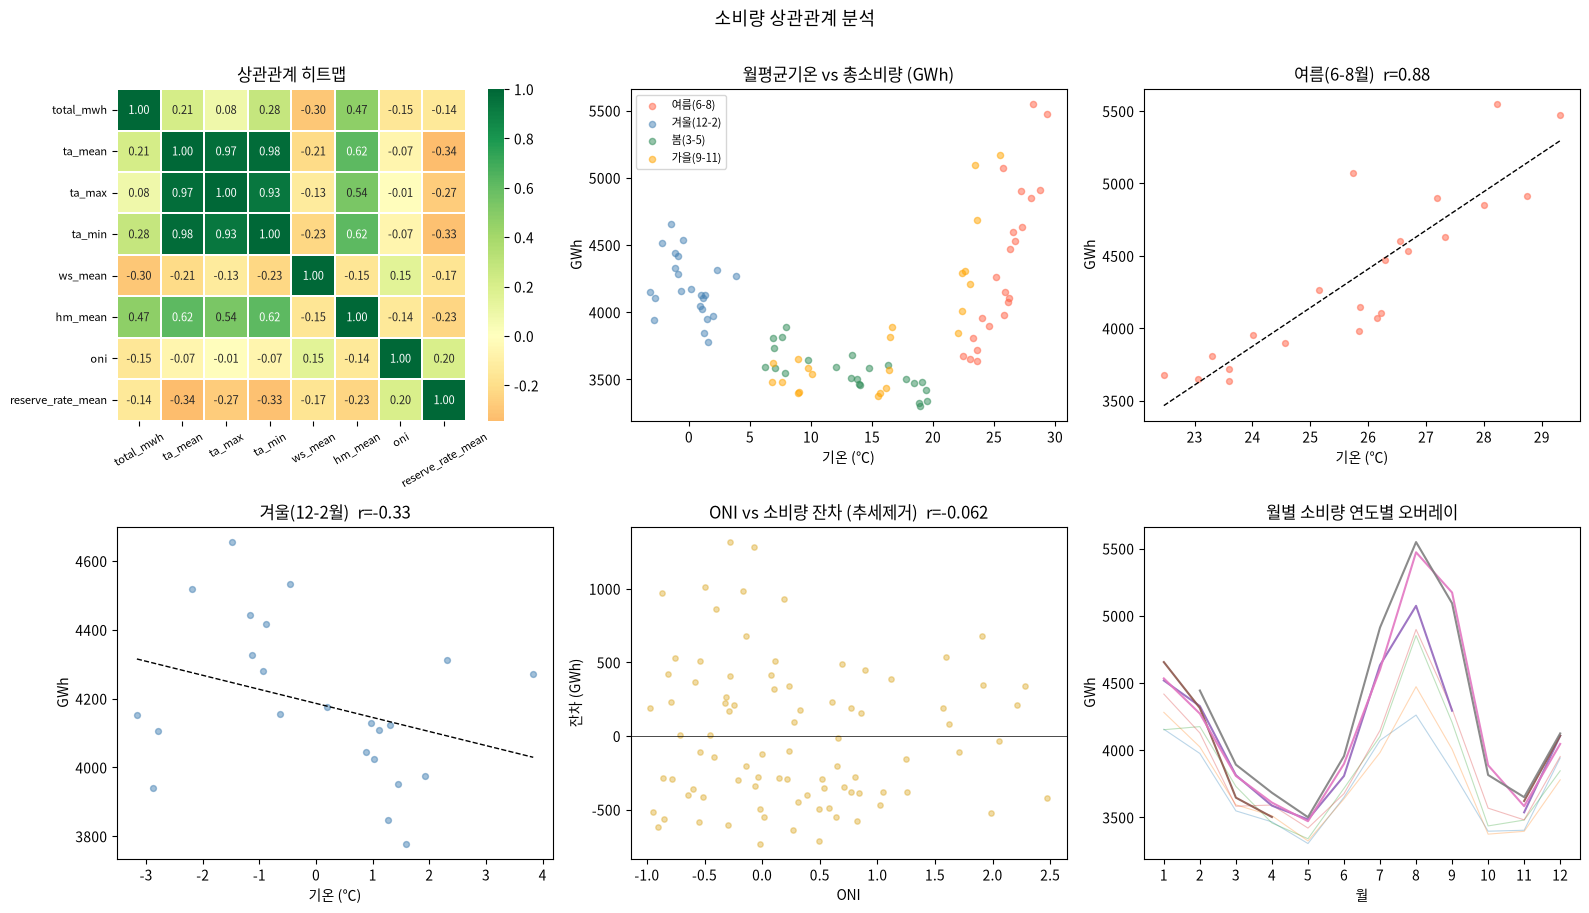


소비량-기온 r=0.213
소비량-ONI  r=-0.062  (추세제거 후 잔차 기준)
소비량-습도 r=0.473
소비량-풍속 r=-0.300

→ 기온 단독 상관이 낮은 이유: U자형 비선형 (여름 냉방↑, 겨울 난방↑)
  CDD/HDD 변수가 이 비선형성을 흡수함 → 섹션 4에서 생성


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# ── 상관관계 히트맵 ────────────────────────────────────────────────────────
corr_cols = ['total_mwh', 'ta_mean', 'ta_max', 'ta_min', 'ws_mean', 'hm_mean', 'oni', 'reserve_rate_mean']
corr = merged[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=axes[0, 0], annot_kws={'size': 8}, linewidths=0.3)
axes[0, 0].set_title('상관관계 히트맵')
axes[0, 0].tick_params(axis='x', rotation=30, labelsize=8)
axes[0, 0].tick_params(axis='y', labelsize=8)

# ── 기온 vs 소비량 (계절 구분) ─────────────────────────────────────────────
def season(m):
    if m in (6, 7, 8):   return '여름(6-8)'
    if m in (12, 1, 2):  return '겨울(12-2)'
    if m in (3, 4, 5):   return '봄(3-5)'
    return '가을(9-11)'

season_colors = {'여름(6-8)': 'tomato', '겨울(12-2)': 'steelblue',
                 '봄(3-5)': 'seagreen', '가을(9-11)': 'orange'}
merged['season'] = merged['month'].apply(season)

for s, c in season_colors.items():
    sub = merged[merged['season'] == s]
    axes[0, 1].scatter(sub['ta_mean'], sub['total_mwh'] / 1e3, color=c, alpha=0.5, s=20, label=s)
axes[0, 1].set_title('월평균기온 vs 총소비량 (GWh)')
axes[0, 1].set_xlabel('기온 (℃)'); axes[0, 1].set_ylabel('GWh')
axes[0, 1].legend(fontsize=8)

# ── U자형 비선형성 (여름/겨울 분리) ───────────────────────────────────────
for ax, months, label, c in [
    (axes[0, 2], [6, 7, 8],   '여름(6-8월)',  'tomato'),
    (axes[1, 0], [12, 1, 2],  '겨울(12-2월)', 'steelblue'),
]:
    sub = merged[merged['month'].isin(months)]
    ax.scatter(sub['ta_mean'], sub['total_mwh'] / 1e3, alpha=0.5, s=18, color=c)
    z = np.polyfit(sub['ta_mean'], sub['total_mwh'] / 1e3, 1)
    xr = np.linspace(sub['ta_mean'].min(), sub['ta_mean'].max(), 50)
    ax.plot(xr, np.polyval(z, xr), 'k--', lw=1)
    r = sub[['ta_mean', 'total_mwh']].corr().iloc[0, 1]
    ax.set_title(f'{label}  r={r:.2f}')
    ax.set_xlabel('기온 (℃)'); ax.set_ylabel('GWh')

# ── ONI vs 소비량 (추세 제거 후 잔차) ─────────────────────────────────────
from sklearn.linear_model import LinearRegression
mask = merged[['year', 'total_mwh']].notna().all(axis=1)
X_yr = merged.loc[mask, 'year'].values.reshape(-1, 1)
y_mwh = merged.loc[mask, 'total_mwh'].values
lr = LinearRegression().fit(X_yr, y_mwh)
merged.loc[mask, 'resid'] = y_mwh - lr.predict(X_yr)

sub_oni = merged.dropna(subset=['oni', 'resid'])
axes[1, 1].scatter(sub_oni['oni'], sub_oni['resid'] / 1e3, alpha=0.4, s=15, color='goldenrod')
r_oni = sub_oni[['oni', 'resid']].corr().iloc[0, 1]
axes[1, 1].axhline(0, color='k', lw=0.5)
axes[1, 1].set_title(f'ONI vs 소비량 잔차 (추세제거)  r={r_oni:.3f}')
axes[1, 1].set_xlabel('ONI'); axes[1, 1].set_ylabel('잔차 (GWh)')

# ── 월별 소비량 시계열 (연도 오버레이) ─────────────────────────────────────
pivot_yr = merged.pivot_table(index='month', columns='year', values='total_mwh')
for yr in pivot_yr.columns:
    alpha = 0.3 if yr < merged['year'].max() - 3 else 0.9
    lw = 0.8 if yr < merged['year'].max() - 3 else 1.5
    axes[1, 2].plot(pivot_yr.index, pivot_yr[yr] / 1e3, alpha=alpha, lw=lw, label=str(yr))
axes[1, 2].set_title('월별 소비량 연도별 오버레이')
axes[1, 2].set_xlabel('월'); axes[1, 2].set_ylabel('GWh')
axes[1, 2].set_xticks(range(1, 13))

plt.suptitle('소비량 상관관계 분석', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n소비량-기온 r={corr.loc['ta_mean','total_mwh']:.3f}")
print(f"소비량-ONI  r={r_oni:.3f}  (추세제거 후 잔차 기준)")
print(f"소비량-습도 r={corr.loc['hm_mean','total_mwh']:.3f}")
print(f"소비량-풍속 r={corr.loc['ws_mean','total_mwh']:.3f}")
print()
print("→ 기온 단독 상관이 낮은 이유: U자형 비선형 (여름 냉방↑, 겨울 난방↑)")
print("  CDD/HDD 변수가 이 비선형성을 흡수함 → 섹션 4에서 생성")

---
## 4. Feature Engineering

| 피처 | 계산 방법 | 목적 |
|---|---|---|
| `cdd` | Σ max(0, ta_mean − 24℃) 일별 합산 → 월 | 냉방 부하 (여름) |
| `hdd` | Σ max(0, 18℃ − ta_mean) 일별 합산 → 월 | 난방 부하 (겨울) |
| `thi` | 1.8T − 0.55(1−RH/100)(1.8T−26) + 32 | 체감 더위 (기온+습도) |
| `oni_3m` | ONI 3개월 이동평균 | ENSO 지연 반응 |

CDD/HDD 월별 샘플:


,year,month,cdd,hdd
0,2006,1,0.000000,564.312500
6,2006,7,13.779167,0.000000
12,2007,1,0.000000,544.729167
18,2007,7,28.716667,0.000000
24,2008,1,0.000000,610.300000
30,2008,7,42.795833,0.000000


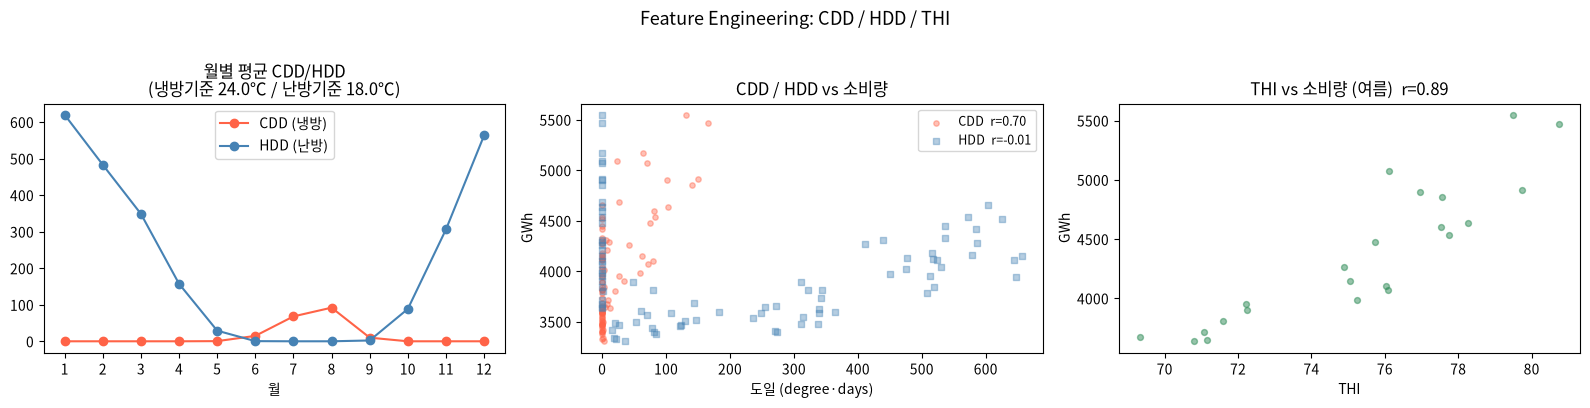


기온 단독    r=0.213
CDD          r=0.696
HDD          r=-0.008
THI (여름)   r=0.892

→ CDD/HDD가 기온 단독보다 소비량과 더 강한 상관을 보임


In [ ]:
COOL_BASE = 24.0
HEAT_BASE = 18.0

# ── CDD / HDD (일별 → 월별 합산) ─────────────────────────────────────────
asos_clean_d['cdd_d'] = (asos_clean_d['ta_mean'] - COOL_BASE).clip(lower=0)
asos_clean_d['hdd_d'] = (HEAT_BASE - asos_clean_d['ta_mean']).clip(lower=0)

cdd_monthly = asos_clean_d.groupby(['year', 'month']).agg(
    cdd=('cdd_d', 'sum'),
    hdd=('hdd_d', 'sum'),
).reset_index()

# ── THI (월별 평균값으로 계산) ────────────────────────────────────────────
def calc_thi(ta, rh):
    return 1.8 * ta - 0.55 * (1 - rh / 100) * (1.8 * ta - 26) + 32

asos_clean_m['thi'] = calc_thi(asos_clean_m['ta_mean'], asos_clean_m['hm_mean'])

# ── ONI 3개월 이동평균 ────────────────────────────────────────────────────
oni_clean_sorted = oni_clean.sort_values(['year', 'month']).copy()
oni_clean_sorted['oni_3m'] = oni_clean_sorted['oni'].rolling(3, min_periods=1).mean()

print("CDD/HDD 월별 샘플:")
display(cdd_monthly[cdd_monthly['month'].isin([1, 7])].head(6))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# CDD/HDD 월별 평균
cdd_avg = cdd_monthly.groupby('month')[['cdd', 'hdd']].mean()
cdd_avg.plot(ax=axes[0], marker='o', color=['tomato', 'steelblue'])
axes[0].set_title(f'월별 평균 CDD/HDD\n(냉방기준 {COOL_BASE}℃ / 난방기준 {HEAT_BASE}℃)')
axes[0].set_xlabel('월'); axes[0].set_xticks(range(1, 13))
axes[0].legend(['CDD (냉방)', 'HDD (난방)'])

# CDD vs 소비량 상관
merged2 = merged.merge(cdd_monthly, on=['year', 'month'], how='left')
merged2 = merged2.merge(asos_clean_m[['year', 'month', 'thi']], on=['year', 'month'], how='left')

r_cdd = merged2[['cdd', 'total_mwh']].corr().iloc[0, 1]
r_hdd = merged2[['hdd', 'total_mwh']].corr().iloc[0, 1]
axes[1].scatter(merged2['cdd'], merged2['total_mwh'] / 1e3,
                alpha=0.4, s=15, label=f'CDD  r={r_cdd:.2f}', color='tomato')
axes[1].scatter(merged2['hdd'], merged2['total_mwh'] / 1e3,
                alpha=0.4, s=15, label=f'HDD  r={r_hdd:.2f}', color='steelblue', marker='s')
axes[1].set_title('CDD / HDD vs 소비량')
axes[1].set_xlabel('도일 (degree·days)'); axes[1].set_ylabel('GWh')
axes[1].legend(fontsize=9)

# THI vs 소비량 (여름)
sub_thi = merged2[merged2['month'].isin([6, 7, 8])].dropna(subset=['thi'])
r_thi = sub_thi[['thi', 'total_mwh']].corr().iloc[0, 1]
axes[2].scatter(sub_thi['thi'], sub_thi['total_mwh'] / 1e3,
                alpha=0.5, s=18, color='seagreen')
axes[2].set_title(f'THI vs 소비량 (여름)  r={r_thi:.2f}')
axes[2].set_xlabel('THI'); axes[2].set_ylabel('GWh')

plt.suptitle('Feature Engineering: CDD / HDD / THI', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n기온 단독    r={corr.loc['ta_mean','total_mwh']:.3f}")
print(f"CDD          r={r_cdd:.3f}")
print(f"HDD          r={r_hdd:.3f}")
print(f"THI (여름)   r={r_thi:.3f}")
print("\n→ CDD/HDD가 기온 단독보다 소비량과 더 강한 상관을 보임")

---
## 5. 최종 Feature Matrix & XGBoost 피처 중요도

| 피처 | 타입 | 설명 |
|---|---|---|
| `year` | 수치 | 기저 소비 증가 추세 |
| `month` | 범주(1-12) | 계절성 |
| `district` | 범주 | 구별 소비 수준 차이 |
| `usage_type` | 범주 | 용도별 기온 반응 패턴 |
| `cdd` | 수치 | 냉방 부하 |
| `hdd` | 수치 | 난방 부하 |
| `thi` | 수치 | 체감 더위 |
| `oni` | 수치 | ENSO 신호 |
| `oni_3m` | 수치 | ONI 3개월 평균 (지연 반응) |

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 구별·용도별 feature matrix 생성
feature_df = (
    kepco_clean
    .merge(cdd_monthly,                                       on=['year', 'month'], how='left')
    .merge(asos_clean_m[['year', 'month', 'ta_mean', 'ws_mean', 'hm_mean', 'thi']],
           on=['year', 'month'], how='left')
    .merge(oni_clean_sorted[['year', 'month', 'oni', 'oni_3m']], on=['year', 'month'], how='left')
)

FEATURE_COLS = ['year', 'month', 'district', 'usage_type', 'cdd', 'hdd', 'thi', 'oni', 'oni_3m']
TARGET_COL   = 'consumption_mwh'

feature_df = feature_df[FEATURE_COLS + [TARGET_COL]].dropna(
    subset=['cdd', 'hdd', 'oni', TARGET_COL]
)

print(f"Feature matrix: {feature_df.shape}")
print(f"연도 범위: {feature_df['year'].min()} ~ {feature_df['year'].max()}")
print(f"\n결측률:")
print((feature_df.isnull().mean() * 100).round(2).to_string())
print()
display(feature_df.head(3))

Feature matrix: (15176, 10)
연도 범위: 2014 ~ 2025

결측률:
year               0.0
month              0.0
district           0.0
usage_type         0.0
cdd                0.0
hdd                0.0
thi                0.0
oni                0.0
oni_3m             0.0
consumption_mwh    0.0



,year,month,district,usage_type,cdd,hdd,thi,oni,oni_3m,consumption_mwh
0,2014,1,강남구,주택용,0.0,577.858333,38.282715,-0.28,-0.176667,74732.657
1,2014,1,강남구,일반용,0.0,577.858333,38.282715,-0.28,-0.176667,319929.448
2,2014,1,강남구,교육용,0.0,577.858333,38.282715,-0.28,-0.176667,4333.182


[Train]  R²=0.9870  MAPE=33786.8%
[Test]  R²=0.9714  MAPE=1846.0%


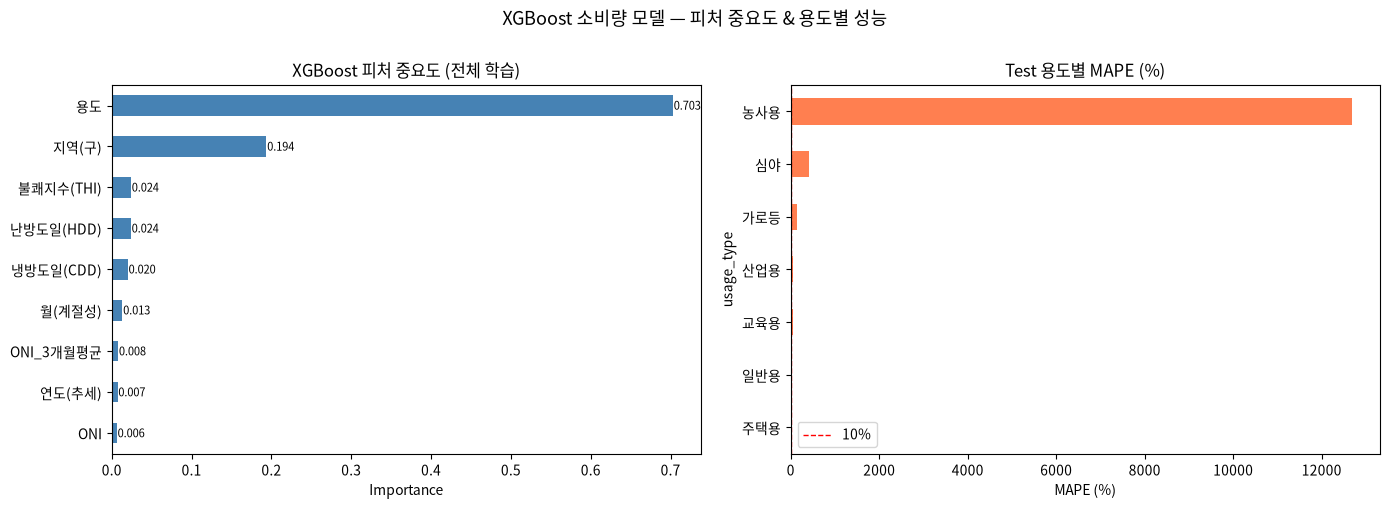


피처 중요도 (높은 순):
용도           0.7030
지역(구)        0.1938
불쾌지수(THI)    0.0241
난방도일(HDD)    0.0240
냉방도일(CDD)    0.0201
월(계절성)       0.0133
ONI_3개월평균    0.0080
연도(추세)       0.0073
ONI          0.0064


In [ ]:
import xgboost as xgb

# 레이블 인코딩 (XGBoost 투입용)
df_enc = feature_df.copy()
le_dist  = LabelEncoder()
le_usage = LabelEncoder()
df_enc['district_id']  = le_dist.fit_transform(df_enc['district'].astype(str))
df_enc['usage_id']     = le_usage.fit_transform(df_enc['usage_type'].astype(str))

MODEL_FEATS = ['year', 'month', 'district_id', 'usage_id', 'cdd', 'hdd', 'thi', 'oni', 'oni_3m']
df_enc = df_enc.dropna(subset=MODEL_FEATS + [TARGET_COL])

X = df_enc[MODEL_FEATS].values
y = df_enc[TARGET_COL].values

# 시계열 분할: ~2022 학습 / 2023~ 테스트
train_mask = df_enc['year'] <= 2022
X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[~train_mask], y[~train_mask]

model_xgb = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
model_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

from sklearn.metrics import r2_score, mean_absolute_percentage_error
for label, yt, yp in [
    ('Train', y_train, model_xgb.predict(X_train)),
    ('Test',  y_test,  model_xgb.predict(X_test)),
]:
    print(f"[{label}]  R²={r2_score(yt, yp):.4f}  MAPE={mean_absolute_percentage_error(yt, yp)*100:.1f}%")

# ── 피처 중요도 ───────────────────────────────────────────────────────────
FEAT_LABELS = {
    'year': '연도(추세)', 'month': '월(계절성)',
    'district_id': '지역(구)', 'usage_id': '용도',
    'cdd': '냉방도일(CDD)', 'hdd': '난방도일(HDD)',
    'thi': '불쾌지수(THI)', 'oni': 'ONI', 'oni_3m': 'ONI_3개월평균',
}
feat_labels = [FEAT_LABELS[f] for f in MODEL_FEATS]

imp = pd.Series(model_xgb.feature_importances_, index=feat_labels).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 피처 중요도 bar
imp.plot(kind='barh', color='steelblue', ax=axes[0])
axes[0].set_title('XGBoost 피처 중요도 (전체 학습)')
axes[0].set_xlabel('Importance')
for i, v in enumerate(imp.values):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

# 용도별 MAPE
test_df = df_enc[~train_mask].copy()
test_df['pred'] = model_xgb.predict(X_test)
mape_by_usage = test_df.groupby('usage_type').apply(
    lambda g: mean_absolute_percentage_error(g[TARGET_COL], g['pred']) * 100
).sort_values()
mape_by_usage.plot(kind='barh', color='coral', ax=axes[1])
axes[1].axvline(10, color='red', ls='--', lw=1, label='10%')
axes[1].set_title('Test 용도별 MAPE (%)')
axes[1].set_xlabel('MAPE (%)'); axes[1].legend()

plt.suptitle('XGBoost 소비량 모델 — 피처 중요도 & 용도별 성능', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print("\n피처 중요도 (높은 순):")
print(imp.sort_values(ascending=False).round(4).to_string())

---
## 6. EDA 결론 요약

In [ ]:
print("=" * 60)
print("  EDA 결론 요약")
print("=" * 60)

print("""
[데이터 품질]
 ASOS   : 결측 없음. 2006~2026 양호.
 KEPCO  : 일부 연도 불완전 파일 (총소비량이 중앙값 60% 미만) → 제거.
          단위 혼재(MWh/kWh)는 kepco_merge.py에서 통일 처리 완료.
 ONI    : 결측 없음. Loader에서 [-2.5, 2.5] 범위 필터 완료.
 EPSIS  : 예비율 < 0 또는 > 100% 소수 존재 → 제거.
 S-DoT  : ta_min -40℃, ta_max 80℃ 등 센서 오류값 존재.
           → 물리적 범위 필터 (ta_mean [-25,40] / ta_min [-25,35] / ta_max [-10,45])
           → ws_mean > 20m/s 제거.
           → ws_mean 결측 43% (센서 미설치 구 多) — 모델에서 선택적 사용.

[정제 기준 반영 위치]
 - S-DoT 정제 기준 → python/preprocess/sdot_transform.py 로 분리 구현 필요.
 - KEPCO 불완전 연도 판단 기준 → EDA에서 확인, train_pipeline.py 사용 시 동일 필터 적용.

[Feature 선택 근거]
 - usage_type, district : 가장 중요한 피처 (구조적 차이)
 - year                 : 기저 소비 증가 추세 반영
 - month                : 계절성
 - CDD / HDD            : 기온 단독보다 비선형 부하를 더 잘 설명
 - THI                  : 여름 냉방 부하 설명력 보완 (선택적)
 - ONI / ONI_3m         : 추세 제거 후 약한 신호 — year와 함께 사용

[다음 단계]
 1. python/preprocess/sdot_transform.py — S-DoT 정제 로직 모듈화
 2. python train_pipeline.py — 실제 데이터로 모델 학습 & pkl 저장
 3. Flask /predict_and_explain 연동
""")

print(f"Feature matrix 최종: {feature_df.shape}")
print(f"Train (~2022): {train_mask.sum()}행  |  Test (2023~): {(~train_mask).sum()}행")

  EDA 결론 요약

[데이터 품질]
 ASOS   : 결측 없음. 2006~2026 양호.
 KEPCO  : 일부 연도 불완전 파일 (총소비량이 중앙값 60% 미만) → 제거.
          단위 혼재(MWh/kWh)는 kepco_merge.py에서 통일 처리 완료.
 ONI    : 결측 없음. Loader에서 [-2.5, 2.5] 범위 필터 완료.
 EPSIS  : 예비율 < 0 또는 > 100% 소수 존재 → 제거.
 S-DoT  : ta_min -40℃, ta_max 80℃ 등 센서 오류값 존재.
           → 물리적 범위 필터 (ta_mean [-25,40] / ta_min [-25,35] / ta_max [-10,45])
           → ws_mean > 20m/s 제거.
           → ws_mean 결측 43% (센서 미설치 구 多) — 모델에서 선택적 사용.

[정제 기준 반영 위치]
 - S-DoT 정제 기준 → python/preprocess/sdot_transform.py 로 분리 구현 필요.
 - KEPCO 불완전 연도 판단 기준 → EDA에서 확인, train_pipeline.py 사용 시 동일 필터 적용.

[Feature 선택 근거]
 - usage_type, district : 가장 중요한 피처 (구조적 차이)
 - year                 : 기저 소비 증가 추세 반영
 - month                : 계절성
 - CDD / HDD            : 기온 단독보다 비선형 부하를 더 잘 설명
 - THI                  : 여름 냉방 부하 설명력 보완 (선택적)
 - ONI / ONI_3m         : 추세 제거 후 약한 신호 — year와 함께 사용

[다음 단계]
 1. python/preprocess/sdot_transform.py — S-DoT 정제 로직 모듈화
 2. python train_pipeline.py — 실제 데이터로 모델 학습 &